In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import warnings 

warnings.filterwarnings("ignore")

In [25]:
def macha(mod):
    print("AIC        :", mod.aic)
    print("BIC        :",mod.bic)
    print("R 2 Squared:", mod.rsquared)
    print("Adjused    :",mod.rsquared_adj)

In [3]:
data = pd.read_csv("50_Startups.csv")

In [4]:
data.columns = ["r_d_spend","Administration","Marketing_Spend","State","Profit"]

In [5]:
data.head()

,r_d_spend,Administration,Marketing_Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [6]:
data.isna().sum()

r_d_spend          0
Administration     0
Marketing_Spend    0
State              0
Profit             0
dtype: int64

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   r_d_spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing_Spend  50 non-null     float64
 3   State            50 non-null     object 
 4   Profit           50 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.1+ KB


In [8]:
data.describe()

,r_d_spend,Administration,Marketing_Spend,Profit
count,50.000000,50.000000,50.000000,50.000000
mean,73721.615600,121344.639600,211025.097800,112012.639200
std,45902.256482,28017.802755,122290.310726,40306.180338
min,0.000000,51283.140000,0.000000,14681.400000
25%,39936.370000,103730.875000,129300.132500,90138.902500
50%,73051.080000,122699.795000,212716.240000,107978.190000
75%,101602.800000,144842.180000,299469.085000,139765.977500
max,165349.200000,182645.560000,471784.100000,192261.830000


In [9]:
data.corr()

,r_d_spend,Administration,Marketing_Spend,Profit
r_d_spend,1.000000,0.241955,0.724248,0.972900
Administration,0.241955,1.000000,-0.032154,0.200717
Marketing_Spend,0.724248,-0.032154,1.000000,0.747766
Profit,0.972900,0.200717,0.747766,1.000000


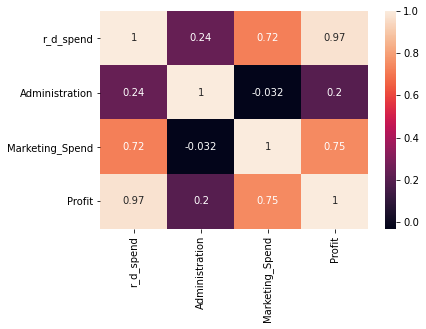

In [10]:
sns.heatmap(data.corr(),annot=True);

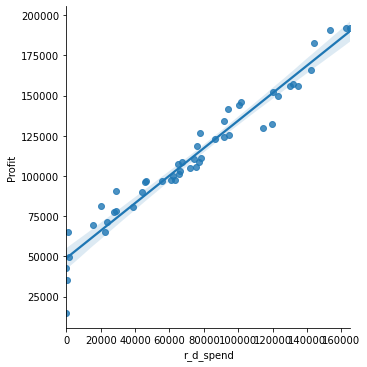

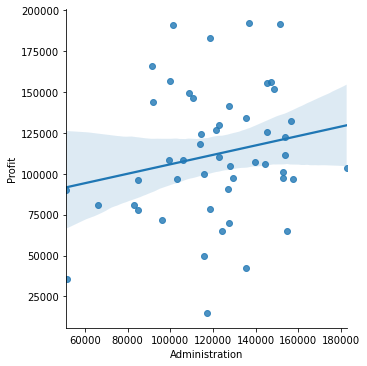

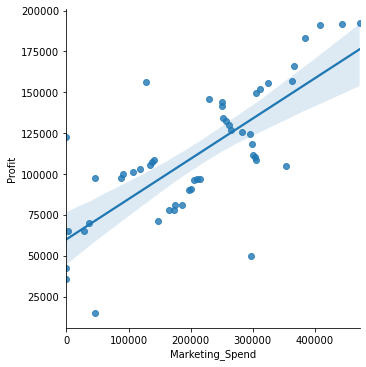

In [11]:
a = data.columns
for i in range(0,3):
    sns.lmplot(x = a[i], y = "Profit",data= data)
    plt.show()

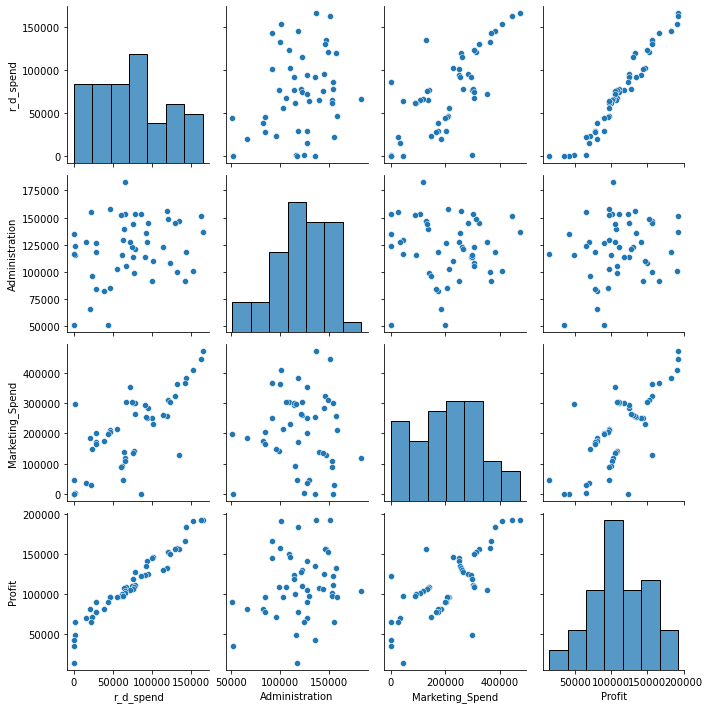

In [12]:
sns.pairplot(data)

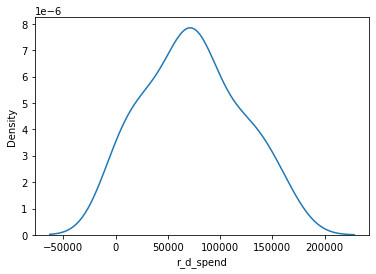

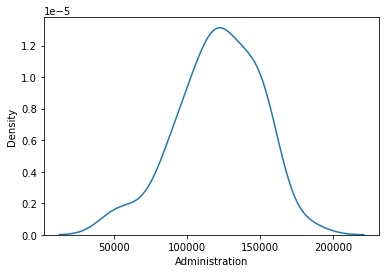

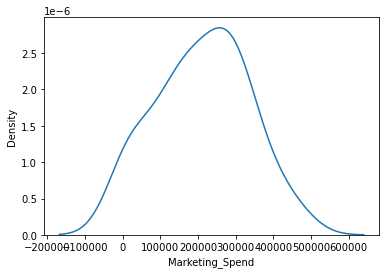

In [13]:
for i in range (0,3):
    sns.distplot(a = data[a[i]], hist=False)
    plt.show()

In [24]:
data["r_d_log"] = np.sqrt(data["r_d_spend"])
data["Marketing_Spend_log"] = np.sqrt(data["Marketing_Spend"])
data["Administration_log"] = np.sqrt(data["Administration"])

In [15]:
data.head(40)

,r_d_spend,Administration,Marketing_Spend,State,Profit,r_d_log,Marketing_Spend_log,Administration_log
0,165349.20,136897.80,471784.10,New York,192261.83,406.631529,686.865416,369.997027
1,162597.70,151377.59,443898.53,California,191792.06,403.234051,666.257105,389.072731
2,153441.51,101145.55,407934.54,Florida,191050.39,391.716109,638.697534,318.033882
3,144372.41,118671.85,383199.62,New York,182901.99,379.963696,619.031195,344.487808
4,142107.34,91391.77,366168.42,Florida,166187.94,376.971272,605.118517,302.310718
5,131876.90,99814.71,362861.36,New York,156991.12,363.148592,602.379747,315.934661
6,134615.46,147198.87,127716.82,California,156122.51,366.899796,357.374901,383.665049
7,130298.13,145530.06,323876.68,Florida,155752.60,360.968323,569.101643,381.484023
8,120542.52,148718.95,311613.29,New York,152211.77,347.192339,558.223333,385.640960
9,123334.88,108679.17,304981.62,California,149759.96,351.190660,552.251410,329.665239


<AxesSubplot:>

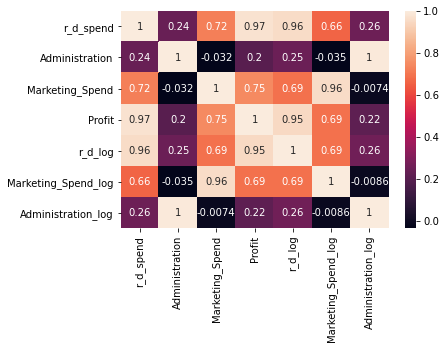

In [16]:
sns.heatmap(data.corr(),annot=True)

In [17]:
data.isnull().sum()

r_d_spend              0
Administration         0
Marketing_Spend        0
State                  0
Profit                 0
r_d_log                0
Marketing_Spend_log    0
Administration_log     0
dtype: int64

In [18]:
import statsmodels.formula.api as smf

In [26]:
mod = smf.ols(formula="Profit~r_d_spend+Administration",data=data).fit()
macha(mod)

AIC        : 1059.6636934567293
BIC        : 1065.3997624730139
R 2 Squared: 0.9478129385009173
Adjused    : 0.9455922124796797


In [27]:
mod = smf.ols(formula="Profit~r_d_spend+Administration",data=data).fit()
macha(mod)

AIC        : 1059.6636934567293
BIC        : 1065.3997624730139
R 2 Squared: 0.9478129385009173
Adjused    : 0.9455922124796797


In [32]:
data.columns.unique()

Index(['r_d_spend', 'Administration', 'Marketing_Spend', 'State', 'Profit',
       'r_d_log', 'Marketing_Spend_log', 'Administration_log'],
      dtype='object')

AIC         1059.6636934567293
BIC         1065.3997624730139
R 2 Squared 0.9478129385009173
Adjused     0.9455922124796797


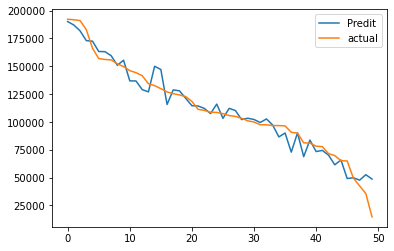

In [20]:
a = "Profit~r_d_spend+Administration"
mod = smf.ols(formula=a,data=data).fit()
macha(mod)
plt.plot(mod.predict())
plt.plot(data.Profit)
plt.legend(("Predit","actual"))

AIC         1058.7714985998055
BIC         1066.419590621518
R 2 Squared 0.9507459940683246
Adjused     0.9475337762901719


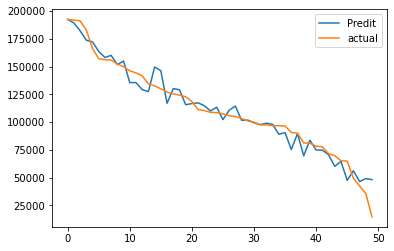

In [21]:
a = "Profit~r_d_spend+Administration+Marketing_Spend"
mod = smf.ols(formula=a,data=data).fit()
macha(mod)
plt.plot(mod.predict())
plt.plot(data.Profit)
plt.legend(("Predit","actual"))

AIC         1058.8730295624773
BIC         1062.6970755733337
R 2 Squared 0.9465353160804392
Adjused     0.9454214684987816


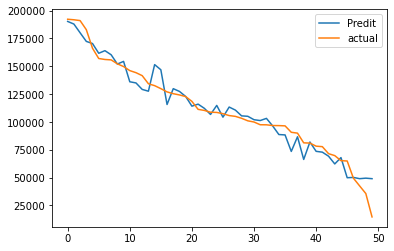

In [23]:
a = "Profit~r_d_spend"
b = "r_d_spend"
mod = smf.ols(formula=a,data=data).fit()
macha(mod)
plt.plot(mod.predict(data["r_d_spend"]))
plt.plot(data.Profit)
plt.legend(("Predit","actual"))